Project 3 Jupyter Notebook
========

### Group: Engel
Authors: Ivan Chan, Kira Obsitnik, Edward Shen, Sage Tulabing, Yuheng Wang, Yixiao Yang


In this notebook, we will estimate a Constant Frisch Elasticity (CFE) demand system and discuss the landscape of the nutritional diet and its adequacy using a set of procedures discussed in the previous lecture. 

This project will use the household food expenditure data in 2019 from **Senegal**, and the Food Nutritional Table (FCT) Spreadsheet that we constructed based on the information provided in the FAO/INFOODS Food Composition Table for Western Africa (WAFCT) 2019 and the USDA FDC Database.

### Set up & Imports
Below are all necessary imports and pip installs for the rest of this project. 

**Please ensure all neccessary files are in the folder before running the below pip install.**

In [2]:
%pip install -r requirements-estimation.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
from ligonlibrary.sheets import read_sheets
import matplotlib.pyplot as plt
from cfe import Regression
import cfe

## Population & Data, <span style="color: red;">*Deliverable [A] Choice of population, with supporting expenditure data* <a name="population-f"></span></a>

We decided to focus on Senegal and the effects that household gender ratios have on food expenditures and nutritional adequacy.  We were able to find a study on men’s daily intake; however, most of these men came from households where women did the cooking.  So, we are going to explore how gender might influence food demand and expenditures for the various main food groups.

The data is stored in a Google Spreadsheet: [https://docs.google.com/spreadsheets/d/1EpdHRbr4QCk_R_uD3kYjo9ZfxOdrX2sFXBsA7xD6vXo/](https://docs.google.com/spreadsheets/d/1EpdHRbr4QCk_R_uD3kYjo9ZfxOdrX2sFXBsA7xD6vXo/). It is also available in a local Excel file `Senegal Data.xlsx`.

We will use the following sheets:
* `Household Characteristics` - One row per household, with demographic columns(household members by characteristics, age/sex group, and log household size).
* `Food Expenditures (2019)` - Records of household food expenditures
* `FCT` - Food Nutrition Table, which stores the nutritional information for every unique food item that appeared in the `Food Expenditures` sheet.
* `RDI` - Recommended Dietary Intake, which stores the Recommended Dietary Intake for age/sex group.
and more...

The first two sheets share the index columns `i` (household ID), `t` (survey wave), and `m` (market/region).

In [4]:
Senegal_Data = '1EpdHRbr4QCk_R_uD3kYjo9ZfxOdrX2sFXBsA7xD6vXo'

**To avoid memory issue in Datahub, we only used urban regions for the remaining analysis.**

In [67]:
x = read_sheets(Senegal_Data,sheet='Food Expenditures (2019)')

d = read_sheets(Senegal_Data,sheet="Household Characteristics")
d.columns.name = 'k'

# Data comes in long format; pivot to wide (one column per food)
x = x.pivot_table(index=['i','t','m'],columns='j_eng',values='Expenditure',
                   aggfunc='sum')
x = x.replace(0,np.nan) # Replace zeros with missing

# Take logs of expenditures; call this y
y = np.log(x)

d.set_index(['i','t','m'],inplace=True)

# NaN in demographic columns means zero people in that category
d = d.fillna(0)
d = d.loc[(slice(None), 2019, slice(None)), :]
y = y.loc[(slice(None), 2019, slice(None)), :]
y.columns.name = 'j'

# Make copies for future estimation scenarios
y_2 = y.copy()
y_3 = y.copy()
y_4 = y.copy()
d_2 = d.copy()
d_3 = d.copy()
d_4 = d.copy()
# Uncomment this code to fix the memory issue
#d = d.loc[(slice(None), 2019, ['dakar', 'diourbel', 'SAINT-LOUIS', 'thies']), :]
#y = y.loc[(slice(None), 2019, ['dakar', 'diourbel', 'SAINT-LOUIS', 'thies']), :]

### Household characteristics dataframe (d)
Missing values in demographic columns are treated as zero (no members of that age/sex group).

In [58]:
print(f"d shape: {d.shape}")
d.head()

d shape: (3510, 19)


,,k,women,girls,boys,men,Males 00-03,Females 00-03,Males 04-08,Females 04-08,Males 09-13,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51+,Females 51+,log HSize
i,t,m,,,,,,,,,,,,,,,,,,,
21001,2019,ziguinchor,1,1,2,1,1,0,1,0,0,1,0,0,0,1,1,0,0,0,1.609438
210010,2019,ziguinchor,3,6,5,2,3,1,2,1,0,3,1,1,0,0,0,3,1,0,2.772589
210011,2019,ziguinchor,3,5,3,3,2,2,0,1,0,2,1,0,1,2,2,1,0,0,2.639057
210012,2019,ziguinchor,1,2,0,1,0,0,0,1,0,0,1,1,0,0,0,1,0,0,1.386294
21002,2019,ziguinchor,2,4,4,2,1,2,0,1,2,1,1,0,1,1,0,1,1,0,2.484907


### Log-expenditure dataframe (y)

Please note that j here are **translated names of the food items**, we need to change the name from j_eng to j in order to not trigger any error.

In [69]:
print(f"y shape (households × foods): {y.shape}")
y.head()

y shape (households × foods): (3537, 134)


,,j,Attieke,Baby milk and flour,Baobab leaves (lalo),Bean/cowpea leaves,Beef,Biscuits,Broken imported rice,Broken local rice,Butter,Cabbage,...,"Traditional beers and wines (soum soum, sung, palm wine, raffia wine, etc.)",Traditional bread,Unsweetened condensed milk,Vinegar/mustard,"Watermelon, Melon",Wheat,Whole imported rice,Wholegrain local rice,Yam,canned peas
i,t,m,,,,,,,,,,,,,,,,,,,,,
221,2019,dakar,NaN,NaN,NaN,NaN,8.006368,NaN,5.991465,5.703782,NaN,4.605170,...,NaN,NaN,5.521461,6.214608,NaN,NaN,NaN,NaN,NaN,NaN
222,2019,dakar,NaN,NaN,NaN,NaN,7.313220,6.214608,NaN,NaN,3.912023,5.298317,...,NaN,NaN,NaN,NaN,NaN,NaN,7.090077,NaN,NaN,NaN
223,2019,dakar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.396930,NaN,4.605170,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
224,2019,dakar,NaN,NaN,NaN,NaN,8.006368,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
225,2019,dakar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Estimation (1) --  With Original Household Characteristics Data

For our estimations, we would run 4 scenarios for our research focus on Gender Differences.

The scenarios are:
* 1 - Estimation with **Unchanged** Household Characteristics Data
* 2 - Estimation with **Only** 4 Characteristics Columns **(women, girls, boy, men)**
* 3 - Estimation with **Only** Age Group/Gender Columns **(eg. Males 19-30, Females 19-30, etc.)**
* 4 - Estimation with **Adjusted** Female vs. Male Columns **(Created by counting the womens, girls as Female; boy & men as Males)**

Below would be **1 - Estimation with **Unchanged** Household Characteristics Data**.

**The following description is adapated from the lecture.**

Let $y_{i}^j$ be log expenditures on food $j$ by household $i$ at a particular time.  We want to estimate a regression that takes the form
$$
      y^j_{i} = A^j(p) + \gamma_j'd_i + \beta_j w_i + \zeta^j_i.
$$
So, a first step is to turn our dataframe for `y` into a series, so we can put it on the left-hand side of this regression.  Then we need to make our dataframe $d$ conform:



In [70]:
y = y.stack().dropna()

d = d.stack().dropna()

# Check that indices are in right places!
assert y.index.names == ['i','t','m','j']
assert d.index.names == ['i','t','m','k']

To set up and run the regression:

In [73]:
result = Regression(y=y,d=d)
result.predicted_expenditures()

i       t     m        j                   
221     2019  dakar    Baobab leaves (lalo)       99.949163
                       Beef                     3498.488894
                       Biscuits                  153.190431
                       Broken imported rice    12130.669318
                       Broken local rice       32493.587971
                                                   ...     
259812  2019  sedhiou  Sweet banana              262.307879
                       Sweet potato              130.119384
                       Tea                       147.513627
                       Tomato paste              129.389410
                       Vinegar/mustard           141.422372
Length: 192989, dtype: float64

Now we can compare predicted log expenditures with actual:

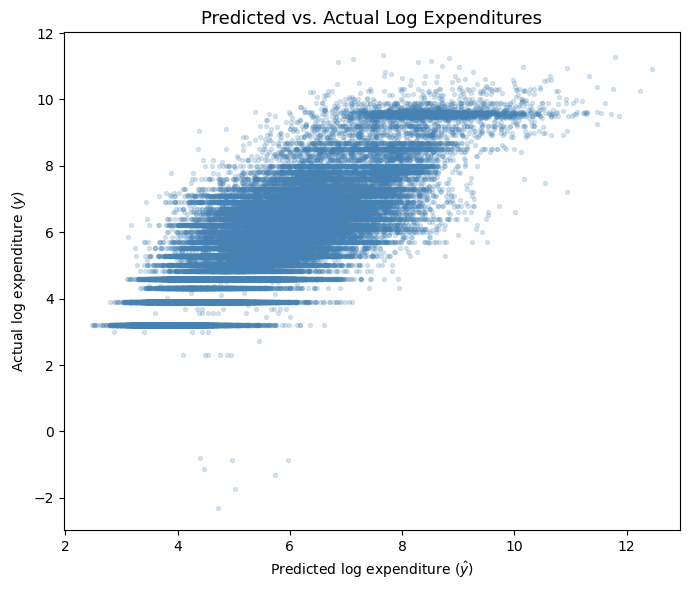

In [74]:
%matplotlib inline

df_fit = pd.DataFrame({
    'y'   : y,
    'yhat': result.get_predicted_log_expenditures()
})

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df_fit['yhat'], df_fit['y'], alpha=0.2, s=8, color='steelblue')

ax.set_xlabel('Predicted log expenditure ($\\hat{y}$)')
ax.set_ylabel('Actual log expenditure ($y$)')
ax.set_title('Predicted vs. Actual Log Expenditures', fontsize=13)
plt.tight_layout()
plt.show()

This figure would be **consist across all scnearios**, as this figure compares expenditure per Household.

## Estimation (2) -- Estimation with **Only** 4 Characteristics Columns **(women, girls, boy, men)**

Below would be **2 - Estimation with Only 4 Characteristics Columns (women, girls, boy, men)**.

In [75]:
d_2 = d_2.loc[:, ['women', 'girls', 'boys', 'men', 'log HSize']]
d_2.head()

,,k,women,girls,boys,men,log HSize
i,t,m,,,,,
21001,2019,ziguinchor,1,1,2,1,1.609438
210010,2019,ziguinchor,3,6,5,2,2.772589
210011,2019,ziguinchor,3,5,3,3,2.639057
210012,2019,ziguinchor,1,2,0,1,1.386294
21002,2019,ziguinchor,2,4,4,2,2.484907


In [76]:
d_2 = d_2.stack().dropna()
y_2 = y_2.stack().dropna()


# Check that indices are in right places!
assert y_2.index.names == ['i','t','m','j']
assert d_2.index.names == ['i','t','m','k']

To set up and run the regression:

In [77]:
# Now run your CFE model
result2 = Regression(y=y_2,d=d_2)

In [78]:
result2.predicted_expenditures()

i       t     m        j                   
221     2019  dakar    Baobab leaves (lalo)       87.053665
                       Beef                     3218.122637
                       Biscuits                  134.839271
                       Broken imported rice    11558.653734
                       Broken local rice       27604.347782
                                                   ...     
259812  2019  sedhiou  Sweet banana              248.548916
                       Sweet potato              114.531587
                       Tea                       137.263007
                       Tomato paste              139.282075
                       Vinegar/mustard           143.544282
Length: 192989, dtype: float64

Now we can compare predicted log expenditures with actual:

## Estimation (3) -- Estimation with **Only** Age Group/Gender Columns **(eg. Males 19-30, etc.)**

Below would be **3 - Estimation with Only Age Group/Gender Columns (eg. Males 19-30, Females 19-30, etc.)**.

In [79]:
d_3 = d_3.loc[:, ~d_3.columns.isin(['women', 'girls', 'boys', 'men'])]
d_3.head()

,,k,Males 00-03,Females 00-03,Males 04-08,Females 04-08,Males 09-13,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51+,Females 51+,log HSize
i,t,m,,,,,,,,,,,,,,,
21001,2019,ziguinchor,1,0,1,0,0,1,0,0,0,1,1,0,0,0,1.609438
210010,2019,ziguinchor,3,1,2,1,0,3,1,1,0,0,0,3,1,0,2.772589
210011,2019,ziguinchor,2,2,0,1,0,2,1,0,1,2,2,1,0,0,2.639057
210012,2019,ziguinchor,0,0,0,1,0,0,1,1,0,0,0,1,0,0,1.386294
21002,2019,ziguinchor,1,2,0,1,2,1,1,0,1,1,0,1,1,0,2.484907


In [80]:
d_3 = d_3.stack().dropna()
y_3 = y_3.stack().dropna()


# Check that indices are in right places!
assert y_3.index.names == ['i','t','m','j']
assert d_3.index.names == ['i','t','m','k']

To set up and run the regression:

In [81]:
# Now run your CFE model
result3 = Regression(y=y_3,d=d_3)

In [82]:
result3.predicted_expenditures()

i       t     m        j                   
221     2019  dakar    Baobab leaves (lalo)      105.412889
                       Beef                     3479.682015
                       Biscuits                  152.118318
                       Broken imported rice    12020.127021
                       Broken local rice       33358.800509
                                                   ...     
259812  2019  sedhiou  Sweet banana              266.387393
                       Sweet potato              132.634007
                       Tea                       147.275258
                       Tomato paste              129.443197
                       Vinegar/mustard           151.368022
Length: 192989, dtype: float64

Now we can compare predicted log expenditures with actual:

## Estimation (4) -- Estimation with **Adjusted** Female vs. Male Columns **(Created by counting the womens, girls as Female; boy & men as Males)**

Below would be **4 - Estimation with Adjusted Female vs. Male Columns (Created by counting the womens, girls as Female; boy & men as Males)**.

In [83]:
d_4['Females'] = d_4['women'] + d_4['girls']
d_4['Males'] = d_4['men'] + d_4['boys']
d_4 = d_4.loc[:, ['Females', 'Males', 'log HSize']]
d_4.head()

,,k,Females,Males,log HSize
i,t,m,,,
21001,2019,ziguinchor,2,3,1.609438
210010,2019,ziguinchor,9,7,2.772589
210011,2019,ziguinchor,8,6,2.639057
210012,2019,ziguinchor,3,1,1.386294
21002,2019,ziguinchor,6,6,2.484907


In [84]:
d_4 = d_4.stack().dropna()
y_4 = y_4.stack().dropna()


# Check that indices are in right places!
assert y_4.index.names == ['i','t','m','j']
assert d_4.index.names == ['i','t','m','k']

To set up and run the regression:

In [85]:
# Now run your CFE model
result4 = Regression(y=y_4,d=d_4)

In [86]:
result4.predicted_expenditures()

i       t     m        j                   
221     2019  dakar    Baobab leaves (lalo)       94.365025
                       Beef                     3084.989193
                       Biscuits                  140.412838
                       Broken imported rice    10910.855922
                       Broken local rice       31282.713294
                                                   ...     
259812  2019  sedhiou  Sweet banana              231.504184
                       Sweet potato              106.962523
                       Tea                       128.240031
                       Tomato paste              156.866409
                       Vinegar/mustard           143.197705
Length: 192989, dtype: float64

Now we can compare predicted log expenditures with actual:

## Demand System, <span style="color: red;">*Deliverable [A] Estimate Demand System* <a name="population-f"></span></a>

Now that we have completed the estimation above, we can then proceed to develop a Demand System.

### Frisch elasticities for (1) Estimation with **Unchanged** Household Characteristics Data
Some of the parameters have an interesting interpretation.  First among these are the $\beta$ coefficients, which govern how *income elastic* different goods are (higher values means more elastic).  These are also called *Frisch elasticities*.


In [87]:
result.get_beta().sort_values()

j
Salad (lettuce, Batavia lettuce, etc.)                                     0.373488
Modern bread                                                               0.516095
Fresh fish yaboy or obo (sardinella)                                       0.600534
Biscuits                                                                   0.605759
Shelled or crushed peanuts (noflaye)                                       0.629013
Other herbal teas and infusions n.d.a. (quinquelibat, lemongrass, etc.)    0.656420
Chicken meat                                                               0.717051
Sorrel (bissap) leaves                                                     0.732415
Mil                                                                        0.790047
Pasta                                                                      0.807577
Cucumber                                                                   0.833645
Tea                                                                       

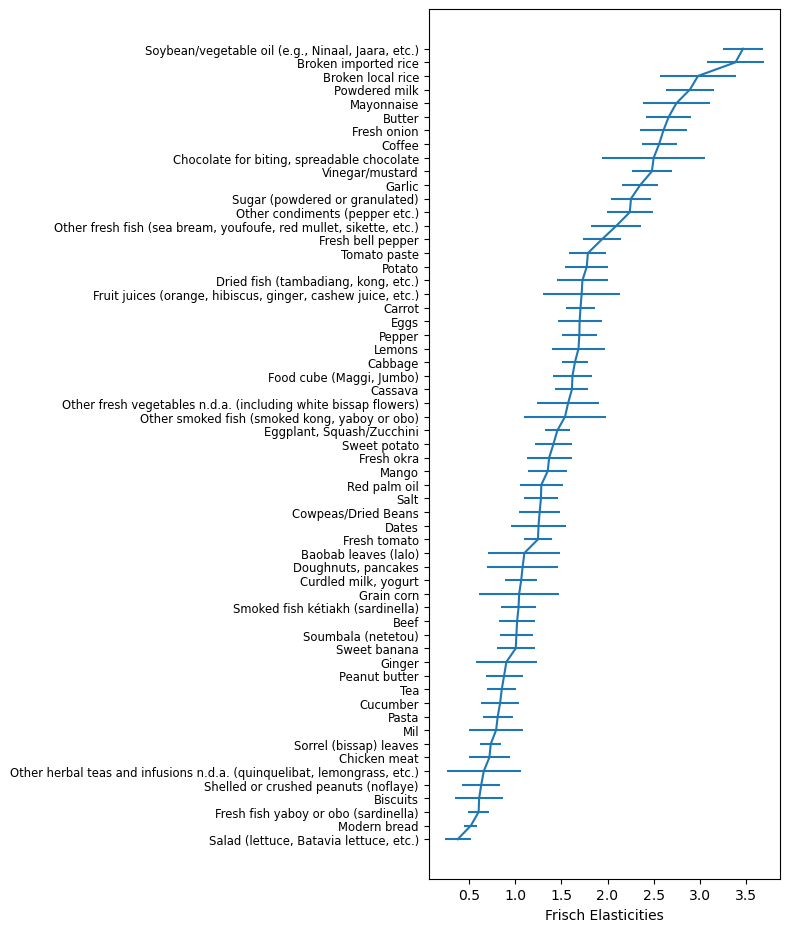

In [88]:
result.graph_beta()
plt.show()

#### Household composition effects
These numbers summarize how household demographic composition shifts demand for each food, based on total expenditure. Each row is a food; each column is a demographic characteristic.

These are captured by the $\gamma_j$ parameters in the regression.

In [89]:
result.gamma

k,women,girls,boys,men,Males 00-03,Females 00-03,Males 04-08,Females 04-08,Males 09-13,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51+,Females 51+,log HSize,Constant
j,,,,,,,,,,,,,,,,,,,,
Baobab leaves (lalo),0.159664,-0.055639,0.117275,0.084560,-0.082204,0.116684,-0.058844,0.156130,-0.107223,0.118701,-0.076111,0.003103,-0.073394,-0.226296,-0.126444,-0.040653,0.019226,-0.019618,-0.203670,4.390147
Beef,0.012524,0.011712,0.004813,0.031614,-0.013938,-0.046417,-0.014350,-0.010340,-0.042280,-0.022413,0.002065,-0.024416,-0.011485,0.032078,0.029826,0.066374,0.091342,0.036500,0.061700,7.774730
Biscuits,-0.346858,-0.292795,0.008234,0.012098,-0.035164,0.352063,0.032958,0.384616,0.012902,0.305912,-0.018962,0.353211,-0.031964,0.396739,-0.005810,0.388717,0.069402,0.370898,-0.131239,4.955624
Broken imported rice,1.755405,1.779331,-1.724235,-1.757143,1.655508,-1.847501,1.681829,-1.813876,1.630202,-1.752768,1.804795,-1.714877,1.815010,-1.614422,1.877260,-1.775262,1.871005,-1.569003,0.338306,8.262444
Broken local rice,0.022811,0.057827,-0.061331,0.126632,0.127708,-0.071218,0.136005,-0.099636,0.052723,0.046037,-0.016096,-0.150510,-0.163758,0.088693,-0.082556,0.145701,0.016250,0.129035,0.025046,8.137215
Butter,-1.414411,-1.679182,-0.142111,0.129793,0.083431,1.649966,0.208553,1.712173,0.078586,1.665756,0.081704,1.606153,-0.167138,1.505132,-0.147975,1.495202,-0.146006,1.408386,0.186750,5.678834
Cabbage,1.482119,1.480916,-0.358279,-0.320652,0.361721,-1.463105,0.392514,-1.447064,0.343018,-1.479424,0.360119,-1.513454,0.376818,-1.408022,0.381743,-1.380541,0.422656,-1.412657,-0.073471,4.918957
Carrot,0.611008,0.584989,0.285118,0.362881,-0.317106,-0.559899,-0.251006,-0.578481,-0.298391,-0.610068,-0.309250,-0.626142,-0.331225,-0.534331,-0.319414,-0.522129,-0.271430,-0.547248,0.011000,4.753706
Cassava,0.080819,0.094818,-0.011119,0.064026,0.031931,-0.069733,0.016618,-0.109083,0.018509,-0.066072,-0.021613,-0.120465,-0.021452,-0.043916,-0.000264,-0.033899,0.032076,-0.033335,0.059395,4.738561


### Frisch elasticities for (2) Estimation with **Only** 4 Characteristics Columns **(women, girls, boy, men)**
Some of the parameters have an interesting interpretation.  First among these are the $\beta$ coefficients, which govern how *income elastic* different goods are (higher values means more elastic).  These are also called *Frisch elasticities*.


In [90]:
result2.get_beta().sort_values()

j
Salad (lettuce, Batavia lettuce, etc.)                                     0.398869
Modern bread                                                               0.524111
Fresh fish yaboy or obo (sardinella)                                       0.615670
Biscuits                                                                   0.629754
Shelled or crushed peanuts (noflaye)                                       0.638225
Other herbal teas and infusions n.d.a. (quinquelibat, lemongrass, etc.)    0.714244
Sorrel (bissap) leaves                                                     0.760048
Chicken meat                                                               0.768898
Pasta                                                                      0.833661
Mil                                                                        0.840361
Tea                                                                        0.883418
Cucumber                                                                  

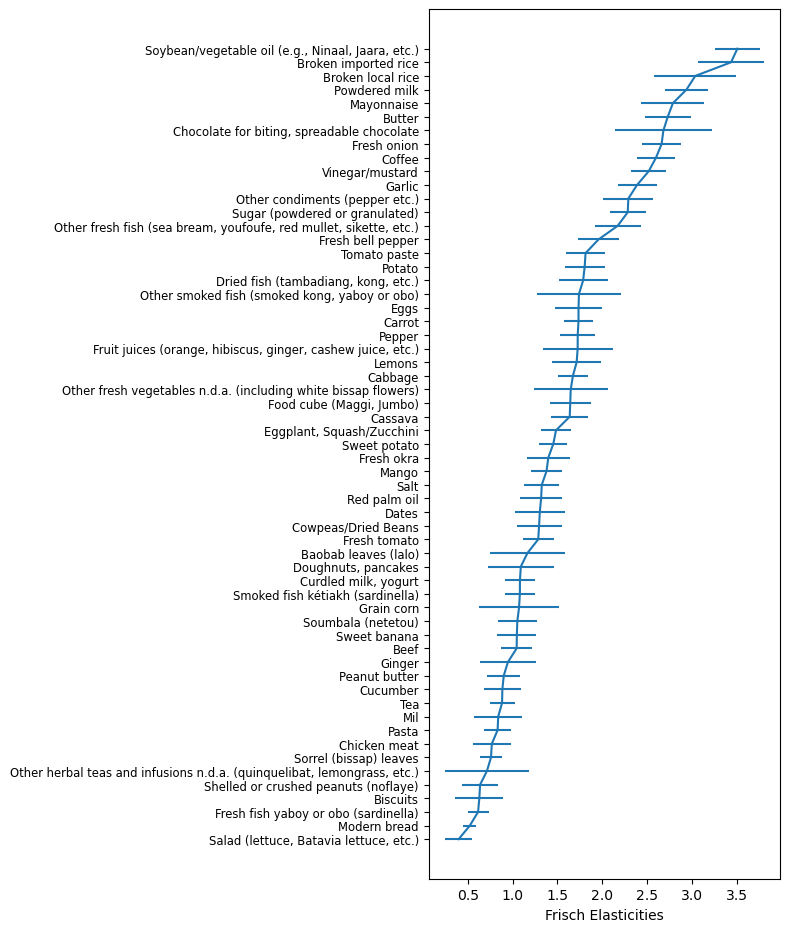

In [91]:
result2.graph_beta()
plt.show()

#### Household composition effects
These numbers summarize how household demographic composition shifts demand for each food, based on total expenditure. Each row is a food; each column is a demographic characteristic.

These are captured by the $\gamma_j$ parameters in the regression.

In [92]:
result2.gamma

k,women,girls,boys,men,log HSize,Constant
j,,,,,,
Baobab leaves (lalo),0.045229,0.063698,0.032505,0.011512,-0.209685,4.406101
Beef,0.052644,-0.007992,-0.010765,0.046586,0.059093,7.773453
Biscuits,0.036107,0.057108,0.008433,-0.003000,-0.104747,4.958249
Broken imported rice,0.107796,-0.015212,-0.051031,0.086183,0.357211,8.264296
Broken local rice,0.122280,0.000300,0.019552,0.015405,0.039765,8.129368
Butter,0.066412,-0.008592,-0.014796,-0.016584,0.180643,5.676545
Cabbage,0.074501,0.013761,0.012058,0.059845,-0.079050,4.917731
Carrot,0.072665,-0.002503,0.001365,0.043699,-0.003355,4.752474
Cassava,0.039698,0.007788,0.003326,0.054977,0.053431,4.737373


### Frisch elasticities for (3) Estimation with **Only** Age Group/Gender Columns **(eg. Males 19-30, etc.)**
Some of the parameters have an interesting interpretation.  First among these are the $\beta$ coefficients, which govern how *income elastic* different goods are (higher values means more elastic).  These are also called *Frisch elasticities*.


In [93]:
result3.get_beta().sort_values()

j
Salad (lettuce, Batavia lettuce, etc.)                                     0.383874
Modern bread                                                               0.520799
Biscuits                                                                   0.607507
Fresh fish yaboy or obo (sardinella)                                       0.611266
Shelled or crushed peanuts (noflaye)                                       0.635954
Other herbal teas and infusions n.d.a. (quinquelibat, lemongrass, etc.)    0.690179
Chicken meat                                                               0.725605
Sorrel (bissap) leaves                                                     0.747769
Mil                                                                        0.780542
Pasta                                                                      0.812990
Cucumber                                                                   0.841076
Tea                                                                       

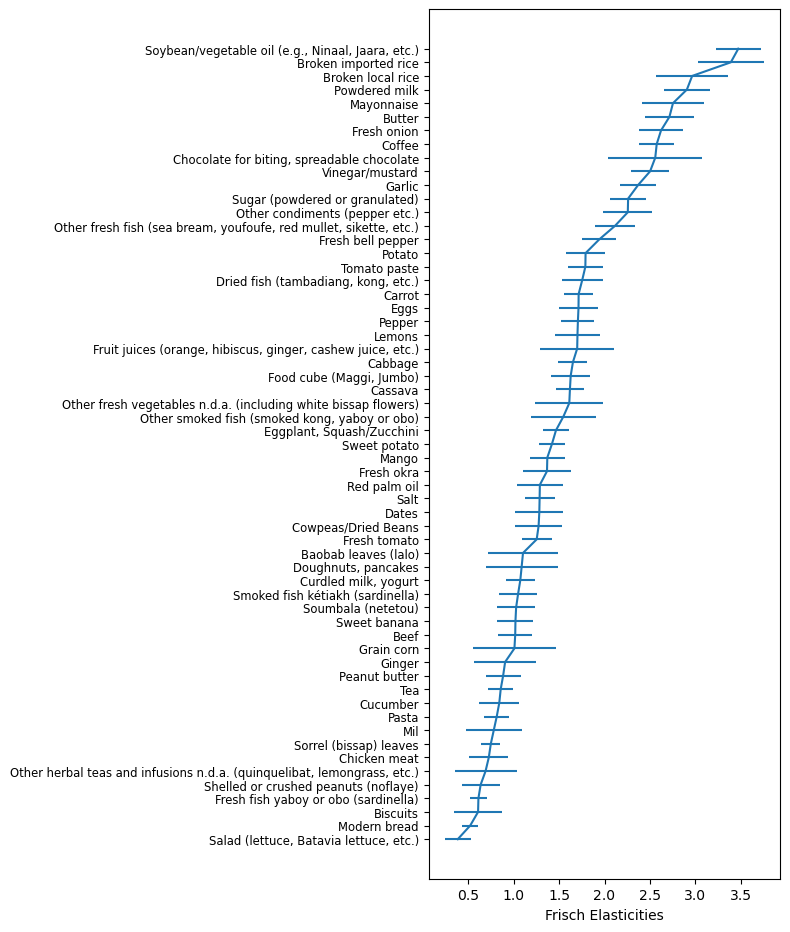

In [94]:
result3.graph_beta()
plt.show()

#### Household composition effects
These numbers summarize how household demographic composition shifts demand for each food, based on total expenditure. Each row is a food; each column is a demographic characteristic.

These are captured by the $\gamma_j$ parameters in the regression.

In [95]:
result3.gamma

k,Males 00-03,Females 00-03,Males 04-08,Females 04-08,Males 09-13,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51+,Females 51+,log HSize,Constant
j,,,,,,,,,,,,,,,,
Baobab leaves (lalo),0.034852,0.061198,0.057544,0.096846,0.010759,0.066859,0.040556,-0.018229,0.018799,-0.062858,-0.034210,0.116243,0.103007,0.150693,-0.213621,4.390578
Beef,-0.009118,-0.034182,-0.009678,0.001367,-0.038081,-0.010247,0.012672,-0.012325,0.020560,0.044761,0.061269,0.078208,0.123564,0.048876,0.061347,7.774923
Biscuits,-0.026102,0.057627,0.042930,0.091485,0.021351,0.011794,-0.012036,0.054009,-0.021468,0.049941,0.008071,0.041416,0.084192,0.023839,-0.131901,4.954993
Broken imported rice,-0.070145,-0.071711,-0.041114,-0.032871,-0.088690,0.026589,0.072353,0.058924,0.056931,0.140776,0.120803,-0.020639,0.110632,0.183507,0.340746,8.261496
Broken local rice,0.067096,-0.015618,0.074166,-0.038044,-0.011742,0.101773,-0.046109,-0.097206,-0.038320,0.112694,0.040231,0.167379,0.147719,0.155337,0.024991,8.135819
Butter,-0.061282,-0.027088,0.062193,0.032926,-0.069224,-0.014366,0.002547,-0.016935,-0.027395,0.097291,-0.014853,0.071468,-0.010092,0.000939,0.172832,5.679925
Cabbage,0.002262,0.016442,0.033707,0.034040,-0.014484,0.000967,0.007920,-0.032566,0.056174,0.072991,0.060546,0.100129,0.099805,0.068825,-0.069002,4.918249
Carrot,-0.031609,0.026146,0.033007,0.006933,-0.013007,-0.024116,-0.008131,-0.036622,0.032945,0.076481,0.043228,0.087713,0.094849,0.064386,0.009458,4.754133
Cassava,0.021038,0.025852,0.004448,-0.013640,0.006466,0.028857,-0.019020,-0.027668,0.042869,0.036853,0.062096,0.045805,0.098102,0.046408,0.060747,4.738763


### Frisch elasticities for (4) Estimation with **Adjusted Female vs. Male** Columns
Some of the parameters have an interesting interpretation.  First among these are the $\beta$ coefficients, which govern how *income elastic* different goods are (higher values means more elastic).  These are also called *Frisch elasticities*.


In [96]:
result4.get_beta().sort_values()

j
Salad (lettuce, Batavia lettuce, etc.)                                     0.417816
Modern bread                                                               0.548424
Biscuits                                                                   0.629649
Shelled or crushed peanuts (noflaye)                                       0.646886
Fresh fish yaboy or obo (sardinella)                                       0.649408
Other herbal teas and infusions n.d.a. (quinquelibat, lemongrass, etc.)    0.736068
Sorrel (bissap) leaves                                                     0.778357
Chicken meat                                                               0.789064
Mil                                                                        0.822558
Pasta                                                                      0.855464
Tea                                                                        0.891576
Cucumber                                                                  

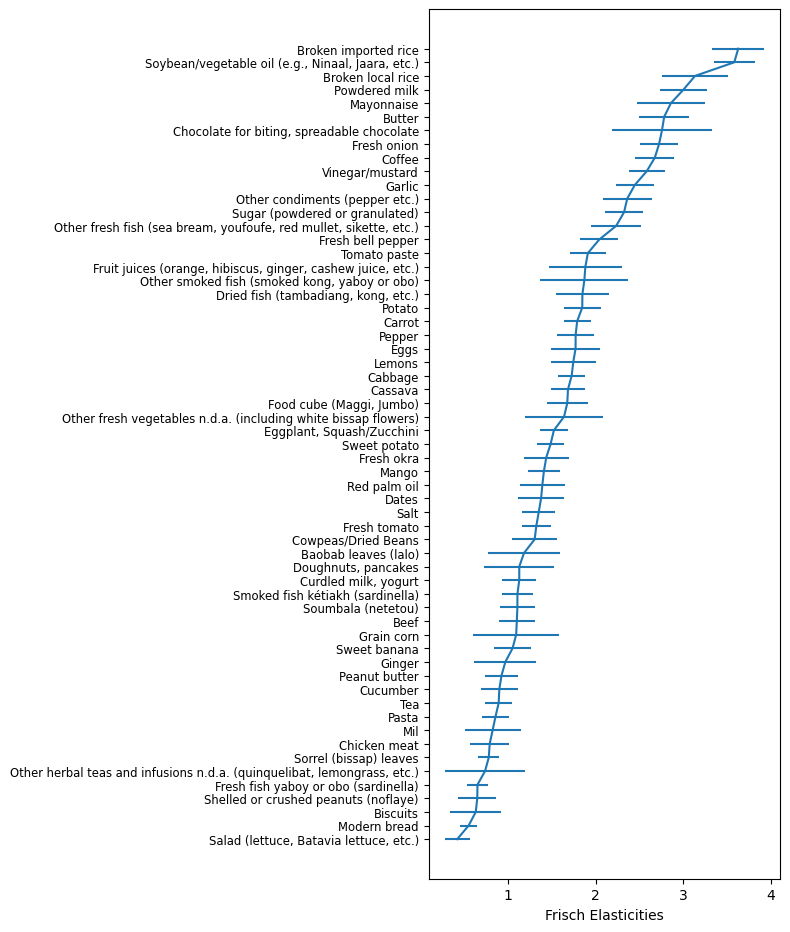

In [97]:
result4.graph_beta()
plt.show()

#### Household composition effects
These numbers summarize how household demographic composition shifts demand for each food, based on total expenditure. Each row is a food; each column is a demographic characteristic.

These are captured by the $\gamma_j$ parameters in the regression.

In [98]:
result4.gamma

k,Females,Males,log HSize,Constant
j,,,,
Baobab leaves (lalo),0.053420,0.022742,-0.193965,4.410528
Beef,0.022514,0.019711,0.039411,7.788866
Biscuits,0.046453,0.001902,-0.095552,4.959290
Broken imported rice,0.045611,0.014109,0.301562,8.259033
Broken local rice,0.049818,0.023526,0.039111,8.133478
Butter,0.025728,-0.010666,0.174884,5.684596
Cabbage,0.042030,0.036957,-0.095232,4.922341
Carrot,0.032632,0.025772,-0.023985,4.759831
Cassava,0.022728,0.027838,0.044967,4.743823


### Visualization on Gammas

To better visualize the effect of Gammas, we will create relevant side-by-side bar charts. For our research focus, we will **only** generate visualization on Gammas for Scenarios **2 and 4**.

**The code was mainly adapated from Professor Ethan.**

In [99]:
result2.to_pickle('result2.pickle')
result3.to_pickle('result3.pickle')
result4.to_pickle('result4.pickle')

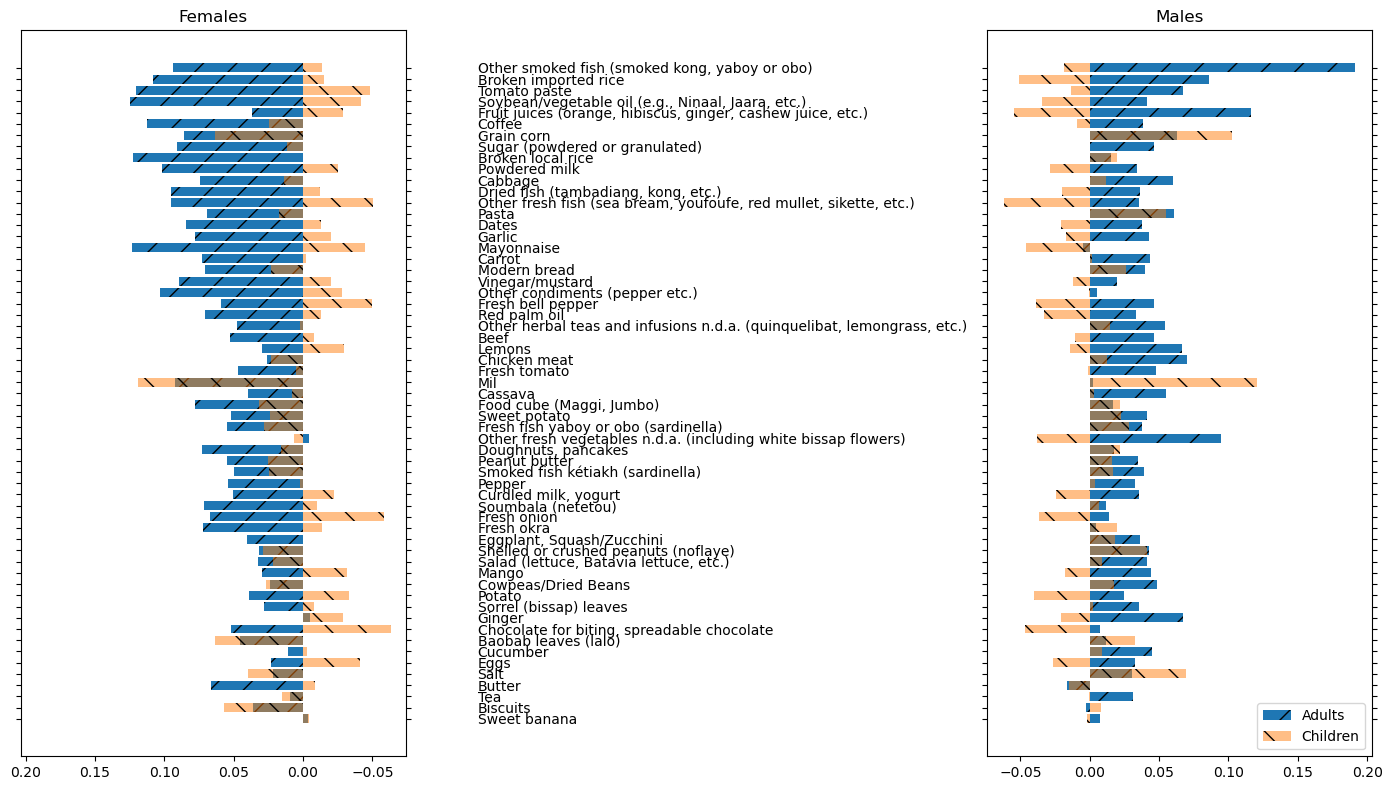

In [100]:
import cfe.regression as rgsn
import matplotlib.pyplot as plt

r2 = rgsn.read_pickle('result2.pickle')

d = r2.gamma[['women','girls','boys','men']]
#se = r2.gamma_se[d.columns]

idx=d[['men','women']].mean(axis=1).sort_values().index

fig,axes = plt.subplots(ncols=2,figsize=(14,8))
axes[0].set_title('Females')
axes[1].set_title('Males')

axes[0].yaxis.tick_right()
axes[0].yaxis.set_ticks_position('both')
axes[1].yaxis.set_ticks_position('both')

axes[1].barh(idx,d.men[idx],hatch='/',label='Adults')
axes[1].barh(idx,d.boys[idx],alpha=0.5,hatch='\\',label='Children')
axes[1].legend()
axes[0].barh(idx,d.women[idx],hatch='/')
axes[0].barh(idx,d.girls[idx],alpha=0.5,hatch='\\')

# Impose same x-axis, but reversed
v = [axes[0].axis()[:2], axes[1].axis()[:2]]
xlims = (min([v[0][1],v[1][0]]), max([v[0][0],v[1][1]]))

axes[0].set_xlim((xlims[1],xlims[0]))
axes[1].set_xlim(xlims)

#axes[0].set_yticklabels(idx,ha='center')
axes[1].set_yticklabels([])
axes[0].tick_params('y',pad=48)

fig.tight_layout()

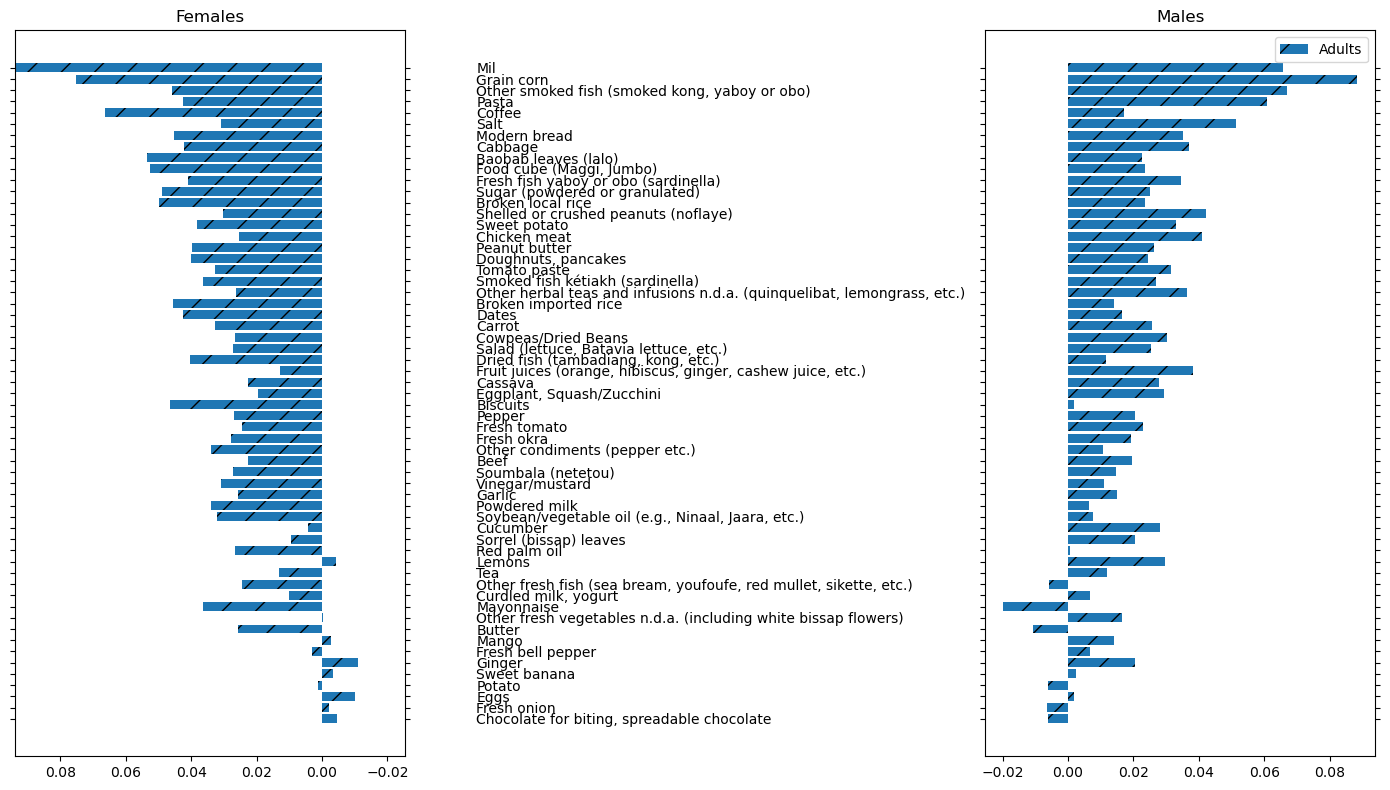

In [104]:
r4 = rgsn.read_pickle('result4.pickle')

d = r4.gamma[['Females', 'Males']]

idx=d[['Males','Females']].mean(axis=1).sort_values().index

fig,axes = plt.subplots(ncols=2,figsize=(14,8))
axes[0].set_title('Females')
axes[1].set_title('Males')

axes[0].yaxis.tick_right()
axes[0].yaxis.set_ticks_position('both')
axes[1].yaxis.set_ticks_position('both')

axes[1].barh(idx,d.Males[idx],hatch='/',label='Adults')
#axes[1].barh(idx,d.boys[idx],alpha=0.5,hatch='\\',label='Children')
axes[1].legend()
axes[0].barh(idx,d.Females[idx],hatch='/')
#axes[0].barh(idx,d.girls[idx],alpha=0.5,hatch='\\')

# Impose same x-axis, but reversed
v = [axes[0].axis()[:2], axes[1].axis()[:2]]
xlims = (min([v[0][1],v[1][0]]), max([v[0][0],v[1][1]]))

axes[0].set_xlim((xlims[1],xlims[0]))
axes[1].set_xlim(xlims)

#axes[0].set_yticklabels(idx,ha='center')
axes[1].set_yticklabels([])
axes[0].tick_params('y',pad=48)

fig.tight_layout()

## The Code below are still Work In Progress

## Nutritional Adequacy of Diet, <span style="color: red;">*Deliverable [B] Nutritional Adequacy of Diet* <a name="population-f"></span></a>

For this deliverable, we will discover the nutritional adequacy of Senegalese Diet, looking it at the **General Adult (19-30) Level** and **Household Level**. 

### Food & Dietary Recommendations

For this part, we will need to import sheets that are relevant to our research. First, we will read in the `FCT` sheet from our Google Sheet for the nutrition information of the food items that appear in the `Food Expenditure (2019)` sheet.

We primarily use the FAO/INFOODS Food Composition Table for Western Africa (WAFCT) 2019 and the USDA FDC Database to match the food items to relevant nutritional information. Beacuse of this, these may **not** accurately reflect the nutritional information of these items.

In [36]:
food_df = read_sheets(Senegal_Data,sheet="FCT")
food_df = food_df.set_index('j')
print(food_df.shape)
food_df

(134, 18)


,WAFCT_Code,FDCID,Energy,Protein,Carbohydrate,Fiber,Calcium,Iron,Zinc,Vitamin A,Thiamin,Riboflavin,Niacin,Vitamin B-6,Folate,Vitamin B-12,Vitamin C,Notes
j,,,,,,,,,,,,,,,,,,
Attieke,,2512377.0,357,0.92,87.3,4.8,75.0,3.99,0.41,0.0,0.051,0.068,0.60,0.050,0,0,0.0,"Flour, cassava"
Baby milk and flour,10_011,NaN,519,12.10,55.4,0.0,358.0,9.30,3.90,467.0,0.520,0.780,3.90,0.330,39,1,43.0,"Infant formula, powder, for 3 months, fortified"
Baobab leaves (lalo),04_001,NaN,62,3.90,19.8,42.9,1244.0,13.70,3.56,286.0,0.100,0.150,6.10,1.500,300,0,19.0,"Baobab, feuilles, fraîches, crues"
Bean/cowpea leaves,04_010,NaN,37,4.40,1.7,4.9,258.0,4.90,0.56,407.0,0.200,0.370,2.10,0.240,120,0,57.0,"Niébé, feuilles, fraîches, crues"
Beef,07_023,NaN,174,20.30,0.0,0.0,11.0,1.20,3.43,0.0,0.110,0.110,8.40,0.230,13,1.8,0.0,"Beef meat, ground, ca. 10% fat, raw"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Watermelon, Melon",05_022,NaN,105,0.50,5.0,0.9,7.0,0.30,0.10,50.0,0.030,0.040,0.20,0.070,0,0,6.0,"Watermelon, fruit, raw"
Wheat,01_074,NaN,329,12.00,59.1,12.2,39.0,5.80,2.00,1.0,0.520,0.090,7.80,0.490,40,0,0.0,"Wheat, whole grains, raw"
Whole imported rice,,169707.0,374,7.51,80.9,1.8,71.0,3.33,1.02,0.0,0.603,0.050,5.05,0.452,257,0,0.0,"Rice, white, long-grain, parboiled, enriched, dry"


We then read in the `RDI` sheet that contains the recommended nutrients intakes.

In [37]:
rdi = read_sheets(Senegal_Data,sheet="RDI")
rdi = rdi.set_index('n')
rdi

,F 00-03,M 00-03,F 04-08,M 04-08,F 09-13,M 09-13,F 14-18,M 14-18,F 19-30,M 19-30,F 31-50,M 31-50,F 51+,M 51+
n,,,,,,,,,,,,,,
Energy,1000.0,1000.0,1200.0,1400.0,1600.0,1800.0,1800.0,2200.0,2000.0,2400.0,1800.0,2200.0,1600.0,2000.0
Protein,13.0,13.0,19.0,19.0,34.0,34.0,46.0,52.0,46.0,56.0,46.0,56.0,46.0,56.0
Fiber,14.0,14.0,16.8,19.6,22.4,25.2,25.2,30.8,28.0,33.6,25.2,30.8,22.4,28.0
Folate,150.0,150.0,200.0,200.0,300.0,300.0,400.0,400.0,400.0,400.0,400.0,400.0,400.0,400.0
Calcium,700.0,700.0,1000.0,1000.0,1300.0,1300.0,1300.0,1300.0,1000.0,1000.0,1000.0,1000.0,1200.0,1000.0
Carbohydrate,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0
Iron,7.0,7.0,10.0,10.0,8.0,8.0,15.0,11.0,18.0,8.0,18.0,8.0,8.0,8.0
Magnesium,80.0,80.0,130.0,130.0,240.0,240.0,360.0,410.0,310.0,400.0,320.0,420.0,320.0,420.0
Niacin,6.0,6.0,8.0,8.0,12.0,12.0,14.0,16.0,14.0,16.0,14.0,16.0,14.0,16.0


### Nutrient Adequacy at the **General Adult (19-30)** Level

Next, we will compute the coverage percentage for the food items. The metrics shows what percentage of Daily Adult RDI is fulfilled by 100g of the food item.

In [38]:
# Select Adult 19-30 for our discovery
rdi_adult = rdi[['F 19-30', 'M 19-30']].apply(pd.to_numeric, errors='coerce').mean(axis=1)
rdi_adult.name = 'Daily_RDI_Adult'

# Select only the nutrients that exist in both your RDI and FCT
common_nutrients = list(set(rdi_adult.index) & set(food_df.columns))

# Filter your food_df to just those numeric nutrient columns
food_nutrients = food_df[common_nutrients].apply(pd.to_numeric, errors='coerce')

# Calculate the coverage percentage: (Nutrient in 100g / Daily Adult Need) * 100
coverage_pct = (food_nutrients.div(rdi_adult[common_nutrients], axis=1) * 100).round(2)

print("Percentage of Daily Adult RDI provided by 100g of food:")
coverage_pct

Percentage of Daily Adult RDI provided by 100g of food:


,Iron,Thiamin,Carbohydrate,Zinc,Folate,Vitamin C,Protein,Calcium,Energy,Niacin,Vitamin B-6,Vitamin A,Vitamin B-12,Riboflavin,Fiber
j,,,,,,,,,,,,,,,
Attieke,30.69,4.43,67.15,4.32,0.00,0.00,1.80,7.5,16.23,4.00,3.85,0.00,0.00,5.67,15.58
Baby milk and flour,71.54,45.22,42.62,41.05,9.75,52.12,23.73,35.8,23.59,26.00,25.38,58.38,41.67,65.00,0.00
Baobab leaves (lalo),105.38,8.70,15.23,37.47,75.00,23.03,7.65,124.4,2.82,40.67,115.38,35.75,0.00,12.50,139.29
Bean/cowpea leaves,37.69,17.39,1.31,5.89,30.00,69.09,8.63,25.8,1.68,14.00,18.46,50.88,0.00,30.83,15.91
Beef,9.23,9.57,0.00,36.11,3.25,0.00,39.80,1.1,7.91,56.00,17.69,0.00,75.00,9.17,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Watermelon, Melon",2.31,2.61,3.85,1.05,0.00,7.27,0.98,0.7,4.77,1.33,5.38,6.25,0.00,3.33,2.92
Wheat,44.62,45.22,45.46,21.05,10.00,0.00,23.53,3.9,14.95,52.00,37.69,0.12,0.00,7.50,39.61
Whole imported rice,25.62,52.43,62.23,10.74,64.25,0.00,14.73,7.1,17.00,33.67,34.77,0.00,0.00,4.17,5.84


#### Heatmap for Illustrating % of Adult RDI met by 100g of Each Food Item

To see the effect more clearly, we created a heatmap to illustrate the percentage of the Adult RDI that is met by 100 grams of each food item.

**We are aware of the unusual statistics for one of the documented food items. This is likely due to human error when compiling and filling the nutritional information in our Sheets.**

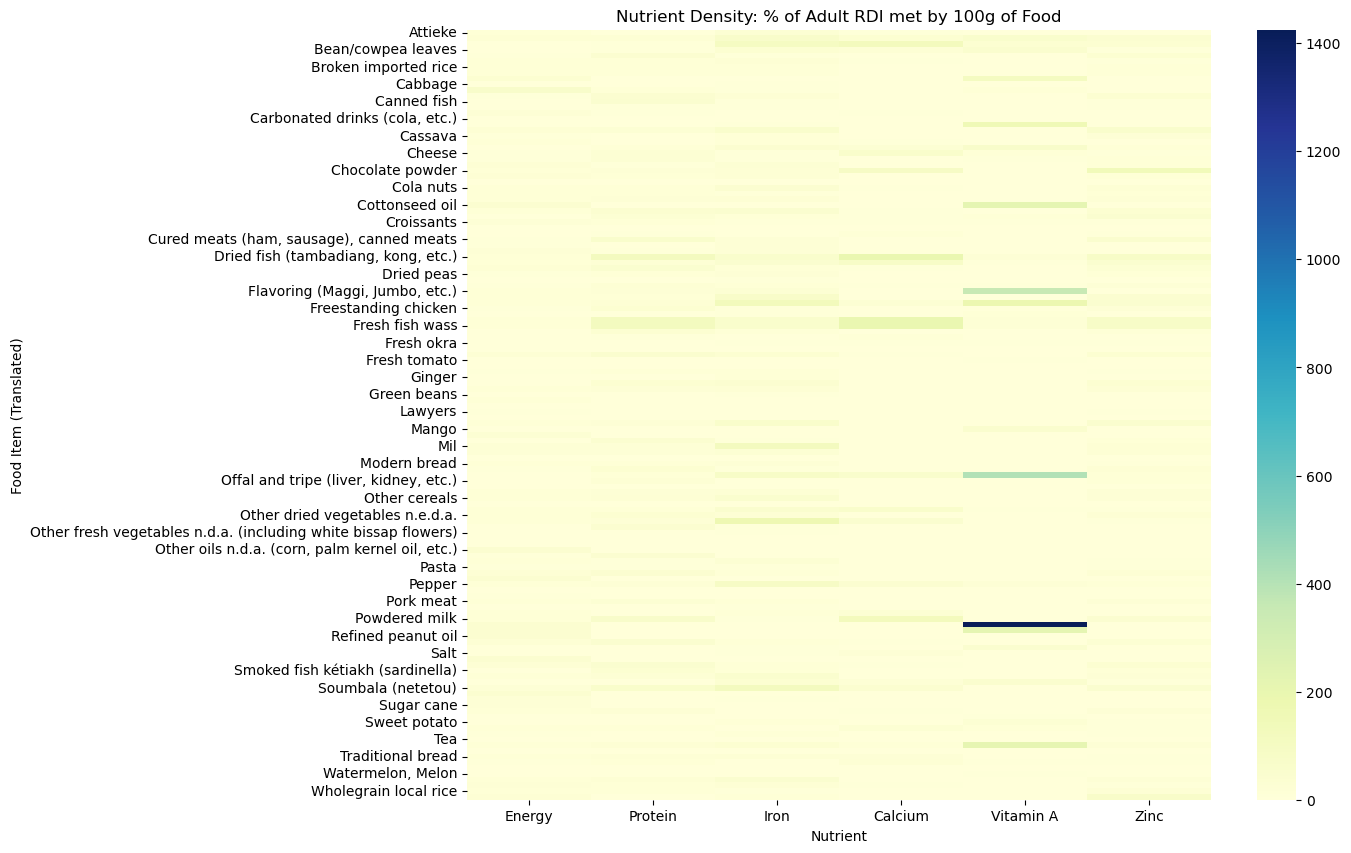

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# You could change the list to the Nutrients you are interested in
target_nutrients = ['Energy', 'Protein', 'Iron', 'Calcium', 'Vitamin A', 'Zinc']

plt.figure(figsize=(12, 10))
sns.heatmap(coverage_pct[target_nutrients], annot=False, cmap='YlGnBu', fmt=".1f")
plt.title("Nutrient Density: % of Adult RDI met by 100g of Food")
plt.ylabel("Food Item (Translated)")
plt.xlabel("Nutrient")
plt.show()

#### Most Nutrient-Efficient Foods for Nutrient Delivery (per 100g)

We also create this bar chart to better visualize the top food items that provide a higher level of a nutrient that we might be interested in.

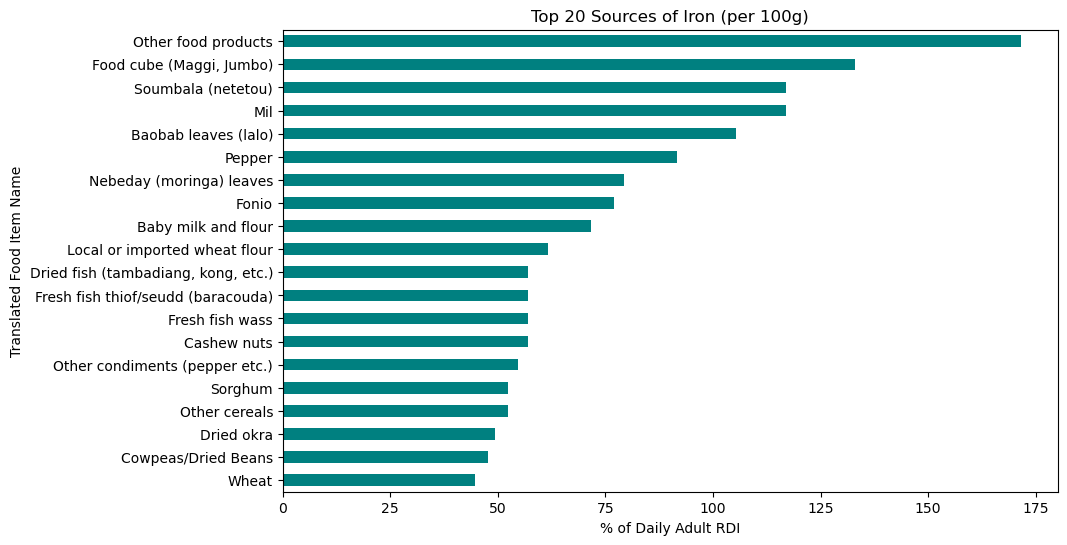

In [40]:
# Change this to whichever nutrient you are interested in
nutrient_to_plot = 'Iron'

top_foods = coverage_pct[nutrient_to_plot].sort_values(ascending=False).head(20)

top_foods.plot(kind='barh', color='teal', figsize=(10, 6))
plt.title(f"Top 20 Sources of {nutrient_to_plot} (per 100g)")
plt.xlabel("% of Daily Adult RDI")
plt.ylabel("Translated Food Item Name")
plt.gca().invert_yaxis() # Highest value at the top
plt.show()

### Nutrient Adequacy at the **Household** Level

To evaluate the nutritional adequacy of household diets, we construct a measure of nutrient intake and compare it to recommended dietary requirements. This process involves several steps that combine expenditure data, food prices, food composition tables (FCT), and recommended dietary allowances (RDI).

#### Procedure
**Step 1: From Expenditures to Quantities**

We begin with household-level food expenditure data. Using observed food prices, we convert expenditures into quantities:

$\text{Quantity}*{ij} = \frac{\text{Expenditure}*{ij}}{\text{Price}_{jm}}$

where ( $i$ ) indexes households and ( $j$ ) indexes food items. Quantities are then standardized into grams to ensure consistency with nutritional data.

**Step 2: From Quantities to Nutrient Intake**

Next, we merge the quantity data with the Food Composition Table (FCT), which provides nutrient content per 100 grams of each food. Nutrient intake is computed as:

$
\text{Intake}*{ijk} = \text{Quantity}*{ij} \times \frac{\text{Nutrient}_{jk}}{100}
$

where ( $k$ ) indexes nutrients (e.g., energy, protein, vitamins). We then aggregate across all foods to obtain total nutrient intake at the household level.

**Step 3: Household Nutrient Requirements**

Household nutrient requirements are constructed using demographic composition data. Each household’s composition (e.g., number of adult males, females, children) is combined with recommended dietary allowances (RDI) for each demographic group. Total household requirements are calculated as:

$
\text{Requirement}*{ik} = \sum*{g} (\text{Household Members}*{ig} \times \text{RDI}*{gk})
$

where ( $g$ ) indexes demographic groups.

** Step 4: Nutrient Adequacy Ratio (NAR) **

We assess adequacy using the Nutrient Adequacy Ratio (NAR), defined as:

$
\text{NAR}*{ik} = \frac{\text{Intake}*{ik}}{\text{Requirement}_{ik}}
$

A value of:

* ( $\text{NAR} \geq 1$ ) indicates that the household meets or exceeds the recommended intake for nutrient ( $k$ ),
* ( $\text{NAR} < 1 $) indicates a deficiency.

To ensure consistency, only nutrients observed in both intake and requirement data are included in the analysis.

#### Food Prices & Expenditures (2019)

In [41]:
p = read_sheets(Senegal_Data, sheet="Food Prices (2019)")

# Filter to only keep the 'standard' units to ensure nutritional accuracy
p_clean = p[p['u_eng'].isin(['Liter', 'kg'])]
p_clean['unit_clean'] = p_clean['u_eng'].str.lower()

# If the list still have duplicates, take the median price for that item/region to remove outliers.
p_final = p_clean.groupby(['m', 'j_eng', 'unit_clean'])['Price'].median().reset_index()

# Compute national median per food + unit
p_final['national_price'] = p_final.groupby(['j_eng', 'unit_clean'])['Price'].transform('median')

# Fill missing prices
p_final['Price'] = p_final['Price'].fillna(p_final['national_price'])

# Drop helper column if needed
p_final = p_final.drop(columns='national_price')
p_final

,m,j_eng,unit_clean,Price
0,SAINT-LOUIS,Beef,kg,2500.000000
1,SAINT-LOUIS,Broken imported rice,kg,357.142857
2,SAINT-LOUIS,Broken local rice,kg,300.000000
3,SAINT-LOUIS,Cabbage,kg,500.000000
4,SAINT-LOUIS,Carrot,kg,400.000000
...,...,...,...,...
1143,ziguinchor,Vinegar/mustard,kg,NaN
1144,ziguinchor,Vinegar/mustard,liter,500.000000
1145,ziguinchor,"Watermelon, Melon",kg,400.000000
1146,ziguinchor,Whole imported rice,kg,14500.000000


In [42]:
# Load the Expenditure data
x = read_sheets(Senegal_Data, sheet="Food Expenditures (2019)")

x = x.groupby(['i', 'm', 'j_eng'])['Expenditure'].sum().reset_index()
x

,i,m,j_eng,Expenditure
0,221,dakar,Beef,3000.0
1,221,dakar,Broken imported rice,400.0
2,221,dakar,Broken local rice,300.0
3,221,dakar,Cabbage,100.0
4,221,dakar,"Caramel, candies, confectionery, etc.",300.0
...,...,...,...,...
93744,259812,sedhiou,Soumbala (netetou),50.0
93745,259812,sedhiou,"Soybean/vegetable oil (e.g., Ninaal, Jaara, etc.)",5000.0
93746,259812,sedhiou,Sugar (powdered or granulated),600.0
93747,259812,sedhiou,Tea,100.0


In [43]:
df = x.merge(p_final, on=['m', 'j_eng'], how='left')
df = df.dropna(subset=['Price'])

# Calculate Quantity
df['quantity'] = df['Expenditure'] / df['Price']

# Standardize Units
df['quantity_g'] = np.where(
    df['unit_clean'] == 'kg',
    df['quantity'] * 1000,
    df['quantity'] * 1000  # assume liter ≈ water for now
)

df

,i,m,j_eng,Expenditure,unit_clean,Price,quantity,quantity_g
0,221,dakar,Beef,3000.0,kg,3000.0,1.000000,1000.000000
1,221,dakar,Broken imported rice,400.0,kg,450.0,0.888889,888.888889
2,221,dakar,Broken local rice,300.0,kg,6750.0,0.044444,44.444444
3,221,dakar,Cabbage,100.0,kg,500.0,0.200000,200.000000
5,221,dakar,Carrot,100.0,kg,400.0,0.250000,250.000000
...,...,...,...,...,...,...,...,...
94557,259812,sedhiou,Red palm oil,250.0,liter,1000.0,0.250000,250.000000
94558,259812,sedhiou,Salt,50.0,kg,50.0,1.000000,1000.000000
94560,259812,sedhiou,Soumbala (netetou),50.0,kg,500.0,0.100000,100.000000
94561,259812,sedhiou,"Soybean/vegetable oil (e.g., Ninaal, Jaara, etc.)",5000.0,liter,1000.0,5.000000,5000.000000


#### Computation

In [105]:
fct = read_sheets(Senegal_Data, sheet="FCT")
fct_long = fct.reset_index().rename(columns={'j': 'j_eng'})
df = df.merge(fct_long, on='j_eng', how='left')

In [106]:
nutrient_cols = ['Energy', 'Protein', 'Carbohydrate', 'Fiber', 'Calcium',
                 'Iron', 'Zinc', 'Vitamin A', 'Thiamin', 'Riboflavin', 'Niacin',
                 'Vitamin B-6', 'Folate', 'Vitamin B-12', 'Vitamin C']  # adjust to your data

for col in nutrient_cols:
    df[col] = df[col].astype(str).str.replace(',', '').str.strip()

df[nutrient_cols] = df[nutrient_cols].apply(pd.to_numeric, errors='coerce')
df['quantity_g'] = pd.to_numeric(df['quantity_g'], errors='coerce')


for col in nutrient_cols:
    df[col + '_intake'] = df[col] * (df['quantity_g'] / 100)

hh_intake = df.groupby('i')[[col + '_intake' for col in nutrient_cols]].sum()
hh_intake

,Energy_intake,Protein_intake,Carbohydrate_intake,Fiber_intake,Calcium_intake,Iron_intake,Zinc_intake,Vitamin A_intake,Thiamin_intake,Riboflavin_intake,Niacin_intake,Vitamin B-6_intake,Folate_intake,Vitamin B-12_intake,Vitamin C_intake
i,,,,,,,,,,,,,,,
221,74921.187086,3518.341920,7751.514197,1628.442784,43879.568847,769.527317,437.001635,70348.903830,49.312587,75.243680,1499.091898,102.420975,14201.315632,471.529216,3791.593885
222,43833.527145,902.926863,4211.183273,321.759362,8509.413838,223.249782,108.113599,126177.675595,28.334298,19.537172,399.779485,40.200430,8989.505049,101.210000,2012.726190
223,7533.698413,598.867411,559.697718,60.514484,4985.247520,84.273224,51.457698,3960.409226,1.952768,6.038328,341.651488,35.274866,1026.316468,232.940000,426.035714
224,59936.220779,1943.789692,5428.258214,703.150000,9652.267857,301.722386,216.920617,32906.809253,30.440818,34.103920,1000.476753,50.133391,8111.277597,67.583312,2472.589286
225,442.166667,12.633333,82.250000,9.000000,402.333333,1.266667,2.560000,191.000000,0.153333,0.631667,3.133333,1.581667,74.166667,1.333333,47.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259611,6673.297619,162.875000,613.472619,234.514286,7974.250000,88.165476,18.935714,610.000000,1.100714,1.508095,90.207143,8.753571,499.678571,41.500000,403.750000
259612,194307.223495,5160.024665,31851.419770,6291.671520,51143.037358,7071.429322,1225.921003,42225.522876,130.265690,98.823075,2003.008222,184.828287,69769.955659,100.647059,1134.611111
259810,89327.207330,2329.817647,14706.848604,2150.365794,17787.988235,3197.448959,562.476510,36101.356209,61.123206,49.808844,900.431279,83.391754,32765.180345,59.147059,187.861111


In [107]:
d_df = read_sheets(Senegal_Data,sheet="Household Characteristics")
d_df = d_df.set_index('i').drop(columns=['t', 'm'])

def clean_demographic(col):
    col = col.strip()
    
    if col.startswith('Females'):
        return col.replace('Females', 'F')
    elif col.startswith('Males'):
        return col.replace('Males', 'M')
    else:
        return col  # keep others (like women/men if needed)

d_df.columns = [clean_demographic(col) for col in d_df.columns]

In [110]:
d_df.columns = d_df.columns.astype(str)
rdi.columns = rdi.columns.astype(str)
groups = d_df.columns.intersection(rdi.columns)

d_filtered = d_df.reindex(hh_intake.index)[groups].fillna(0)
rdi_filtered = rdi[groups]

In [127]:
hh_req_values = d_filtered.values @ rdi_filtered.values.T

hh_requirements = pd.DataFrame(
    hh_req_values,
    index=d_filtered.index,
    columns=rdi_filtered.index
)
hh_requirements = hh_requirements.replace(0, np.nan)

hh_intake = hh_intake.copy()
hh_intake.columns = [col.replace('_intake', '') for col in hh_intake.columns]

nar = hh_intake / hh_requirements

In [ ]:
#hh_requirements

In [ ]:
#hh_intake

In [128]:
nar_clean = nar.replace([np.inf, -np.inf], np.nan)
nar_clean = nar.dropna(axis=1, how='all')
nar_clean

,Calcium,Carbohydrate,Energy,Fiber,Folate,Iron,Niacin,Protein,Riboflavin,Thiamin,Vitamin A,Vitamin B-12,Vitamin B-6,Vitamin C,Zinc
i,,,,,,,,,,,,,,,
221,4.100894,5.962703,4.116549,6.391063,3.944810,7.619082,11.022735,7.888659,7.032120,4.787630,9.770681,21.830056,8.064644,5.416563,5.023007
222,1.418236,5.398953,4.764514,2.498132,5.448185,3.659832,6.246554,4.828486,3.907434,5.782510,38.235659,10.223232,7.584987,7.319004,2.702840
223,1.038593,1.076342,1.076243,0.617495,0.733083,2.006505,6.570221,3.742921,1.509582,0.488192,1.523234,27.730952,7.348930,1.775149,1.608053
224,3.217423,13.918611,9.667132,8.100806,6.759398,6.857327,22.738108,13.133714,9.743977,8.953182,14.307308,9.386571,12.854716,10.302455,8.034097
225,0.182879,0.316346,0.130049,0.189076,0.092708,0.048718,0.111905,0.137319,0.287121,0.069697,0.136429,0.277778,0.564881,0.317778,0.160000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259611,1.049243,0.674146,0.538169,1.350889,0.227127,1.259507,1.048920,0.616951,0.225089,0.169341,0.135556,3.143939,1.167143,1.022152,0.338138
259612,3.432419,16.334061,8.674430,20.062728,17.017062,46.522561,12.839796,11.441296,8.100252,10.765760,5.345003,4.091344,13.690984,1.719108,13.041713
259810,8.893994,56.564802,23.507160,40.420410,40.956475,122.978806,30.014376,22.841349,20.753685,26.575307,22.563348,12.322304,27.797251,1.138552,29.604027


#### Limitation & Interpretation
We have some limitations and assumptions made during the computation for the ratio:
- As discussed before, the nutritional information for the food items **might not** accurately reflect the food items that the Senegalese consume.
- The `Food Price (2019)` sheets contain food prices with units that are **not standardized**. For simplicity, we filtered **only** the items with standard units (kg and Liters).
- For some food prices, we used the median food prices for all regions to simplify the process. Because of this, this might not be an accurate reflection of households in specific regions.

The NAR provides a nutrient-specific measure of adequacy. By examining NAR across nutrients and households, we can identify patterns of nutritional deficiency and assess dietary quality. 

### Visualizations

#### Average/Median Nutrient Adequacy Ratio by Nutrient
This bar chart is constructed to illustrates average NAR by nutrient. With dashed line at $NAR = 1$ to highlight the value of adequate nutrient intake.

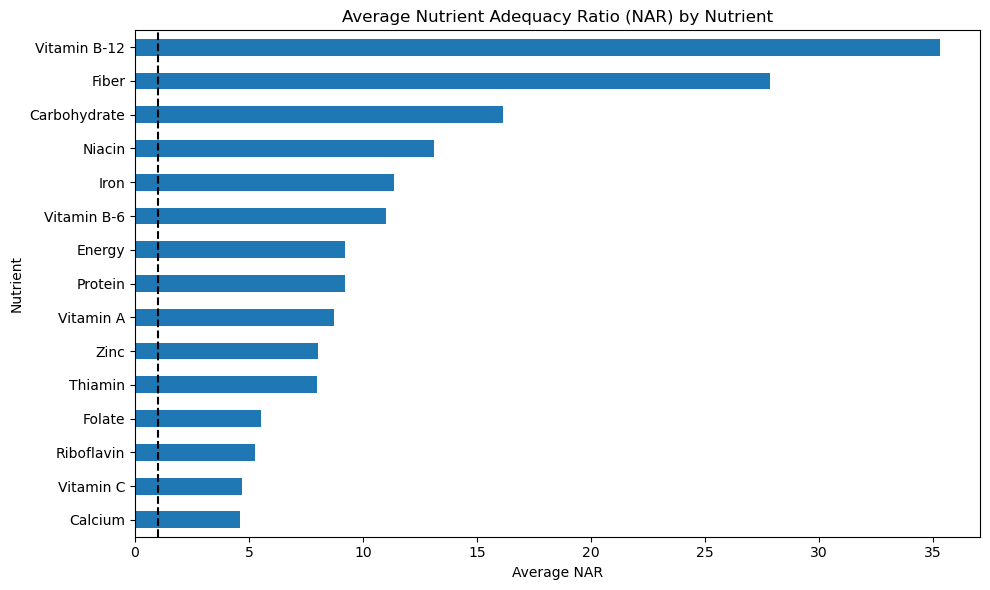

In [132]:
avg_nar = nar_clean.mean().sort_values()

plt.figure(figsize=(10,6))
avg_nar.plot(kind='barh')

plt.axvline(1, linestyle='--', color='black')
plt.title('Average Nutrient Adequacy Ratio (NAR) by Nutrient')
plt.xlabel('Average NAR')
plt.ylabel('Nutrient')

plt.tight_layout()
plt.show()

When interpreting the chart, we noticed overall large NAR values for all nutrients, indicating possible outliers in our NAR values. One alternative chart we constructed is the **Median** Nutrient Adequacy Ratio by Nutrient Bar Chart. This provides somewhat lower NAR values across all nutrients.

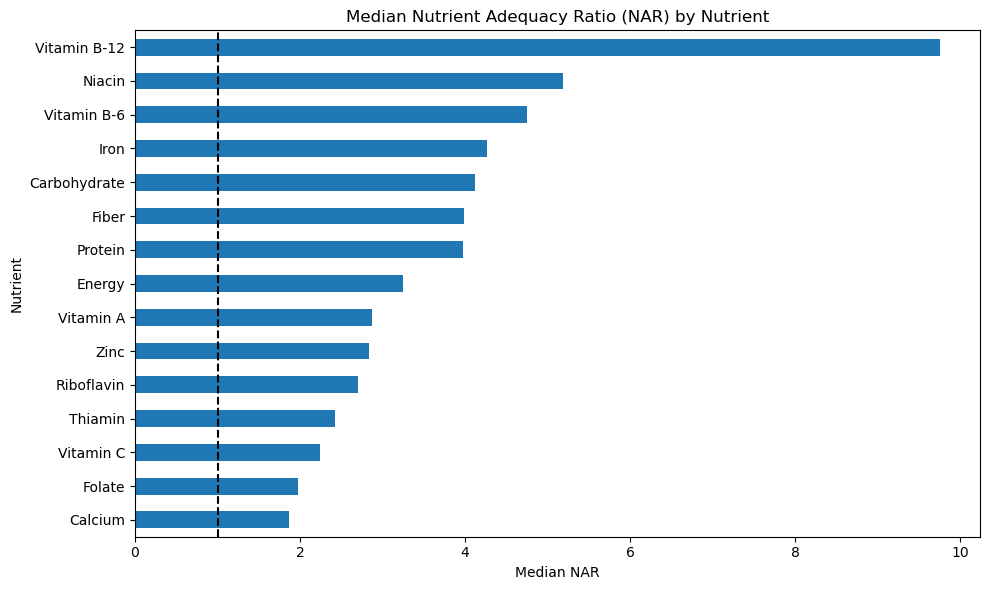

In [134]:
med_nar = nar_clean.median().sort_values()

plt.figure(figsize=(10,6))
med_nar.plot(kind='barh')

plt.axvline(1, linestyle='--', color='black')
plt.title('Median Nutrient Adequacy Ratio (NAR) by Nutrient')
plt.xlabel('Median NAR')
plt.ylabel('Nutrient')

plt.tight_layout()
plt.show()

Another alternative is to set a cutoff value $NAR = 3$, and construct the same chart.

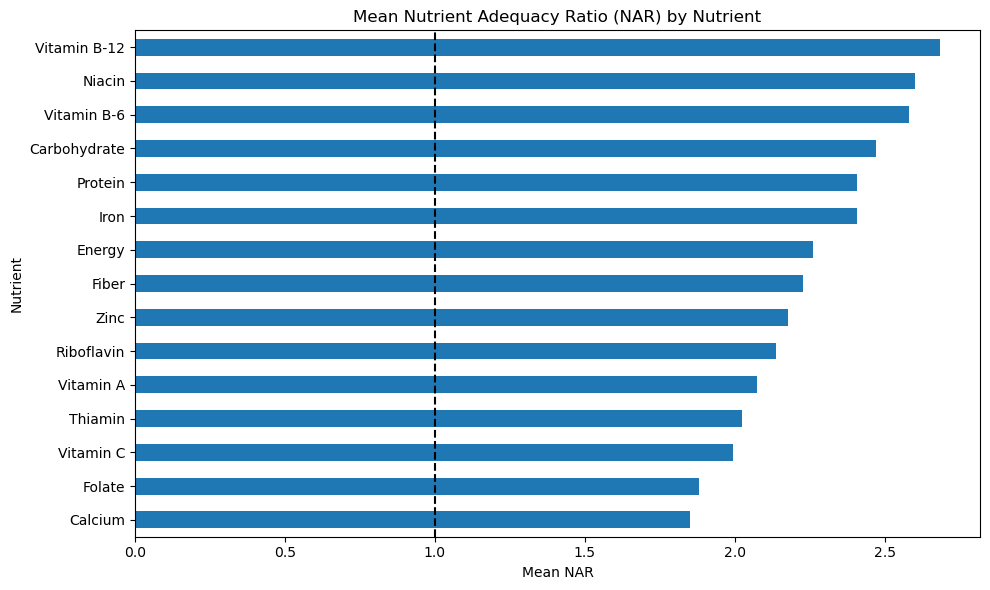

In [141]:
nar_capped = nar_clean.clip(upper=3)
avg_nar_capped = nar_capped.mean().sort_values()

plt.figure(figsize=(10,6))
avg_nar_capped.plot(kind='barh')

plt.axvline(1, linestyle='--', color='black')
plt.title('Mean Nutrient Adequacy Ratio (NAR) by Nutrient')
plt.xlabel('Mean NAR')
plt.ylabel('Nutrient')

plt.tight_layout()
plt.show()

#### Share of Households Below Adequacy ($NAR < 1$)

After looking at the population level, we decide to look at the households that are below adequacy, that is, households with an $NAR <1$. We then construct a bar chart to visualize the proportion of households where they did not intake enough of. 

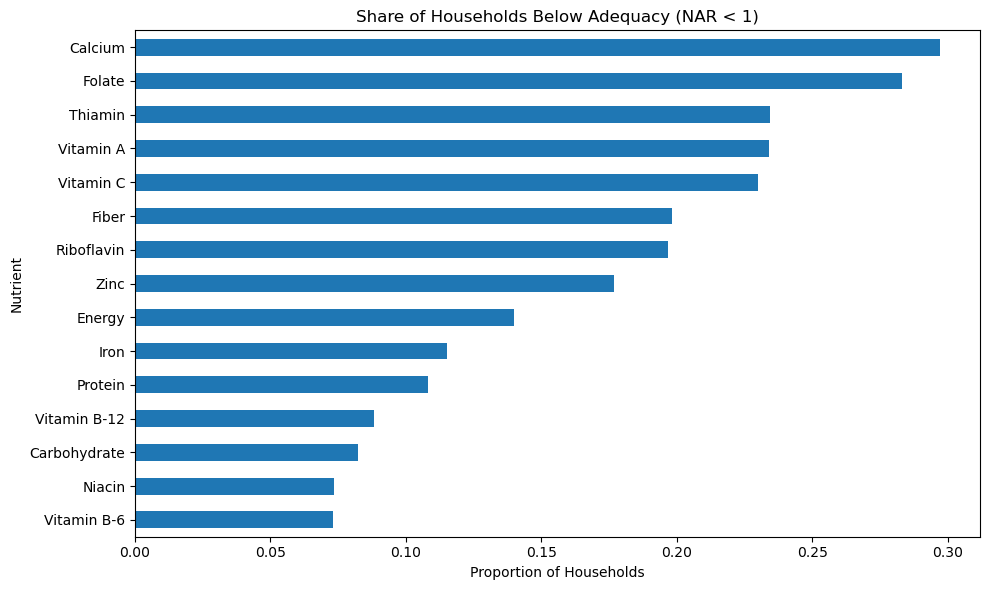

In [119]:
deficiency_rate = (nar_clean < 1).mean().sort_values()

plt.figure(figsize=(10,6))
deficiency_rate.plot(kind='barh')

plt.title('Share of Households Below Adequacy (NAR < 1)')
plt.xlabel('Proportion of Households')
plt.ylabel('Nutrient')

plt.tight_layout()
plt.show()

#### Distribution of Mean Adequacy Ratio (MAR)

Finally, we conclude with a bar chart that draws out the distribution of the Mean Adequacy Ratio that cuts off at $NAR = 1$. We would like to discover how adequate diets are overall.

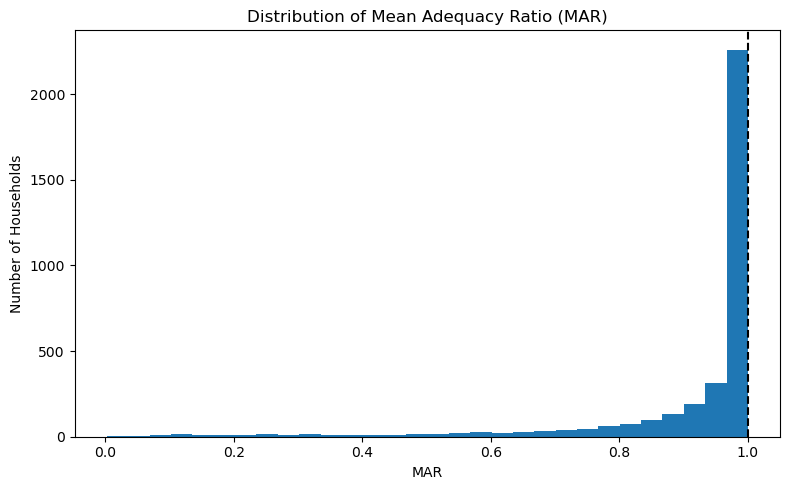

In [120]:
mar = nar_clean.clip(upper=1).mean(axis=1)

plt.figure(figsize=(8,5))
plt.hist(mar, bins=30)

plt.axvline(1, linestyle='--', color='black')
plt.title('Distribution of Mean Adequacy Ratio (MAR)')
plt.xlabel('MAR')
plt.ylabel('Number of Households')

plt.tight_layout()
plt.show()